In [1]:
from oemof.demand import bdew
from oemof.demand import vdi
import pandas as pd
import demandlib
import wetterdienst
import numpy as np

In [2]:
CSV_PATH = r"C:\Users\JONATHANQ\Downloads\Gebäude-2981-heat.csv" #Tabelle von greenventory
JAHR = 2025
HEIZGRENZTEMPERATUR = 15.0
LAT, LON = 48.4406, 7.9761   # Offenburg

In [ ]:
houses_df = pd.read_csv(CSV_PATH, sep=";", decimal=",")

#oemof liest bei manchen Funktionen nur Spalten mit der exakten Bennenung ein, deshalb Anpassen aller entsprechenden Spaltennamen:
houses_df = houses_df.rename(columns= {
    "id" : "name",
    "Gebäudetyp" : "house_type",
    "Bewohner" : "N_Pers",
    "Anzahl der Wohnungen" : "N_WE",
    "Wärmebedarf (kWh/Jahr)" : "Q_Heiz_a", #Zuordnung prüfen
    "Warmwasserbedarf (kWh/Jahr)" : "Q_TWW_a",
    "Strombedarf (kWh/Jahr)" : "W_a"
})

#Gebäudeklassen hinzufügen ÜBERPRÜFEN!
mapping = {
    "Wohngebäude": 1,
    "Mehrfachnutzung": 1,
    "Büro und Verwaltung" : 0,
    "Lager" : 0,
    "Verarbeitendes Gewerbe" : 0,
    "Handel, Instandhaltung, Reparatur" : 0,
    "Land-, Forstwirtschaft, Fischerei" : 0,
    "Gastgewerbe und Gastronomie" : 0,
    "Bildung" : 0,
    "Sonstige Dienstleistungen" : 0,
    "Kunst, Unterhaltung, Erholung" : 0,
    "Sportstätte" : 0,
    "Religiöse Einrichtung" : 0,
    "Energieversorgung" : 0,
    "Gesundheits- und Sozialwesen" : 0
}
houses_df["building_class"] = houses_df["house_type"].map(mapping)

#Parameter in den Spalten an Anforderungen anpassen, ÜBERPRÜFEN
houses_df["house_type"] = houses_df["house_type"].replace({
    "Wohngebäude": "MFH",
    "Mehrfachnutzung": "MFH",
    "Büro und Verwaltung" : "GKO",
    "Lager" : "GBD",
    "Verarbeitendes Gewerbe" : "GHD",
    "Handel, Instandhaltung, Reparatur" : "GHD",
    "Land-, Forstwirtschaft, Fischerei" : "GBD",
    "Gastgewerbe und Gastronomie" : "GGA",
    "Bildung" : "GKO",
    "Sonstige Dienstleistungen" : "GBD",
    "Kunst, Unterhaltung, Erholung" : "GBD",
    "Sportstätte" : "GBD",
    "Religiöse Einrichtung" : "GKO",
    "Energieversorgung" : "GHD",
    "Gesundheits- und Sozialwesen" : "GKO"
})


# houses_df = houses_df[["name","house_type","N_Pers","N_WE","Q_Heiz_a","Q_TWW_a","W_a"]]
houses = houses_df.to_dict(orient="records") #oemof erwartet Häuser als dictionary

In [ ]:
# print(houses_df["house_type"].value_counts())

#substitute with:

# EFH: Einfamilienhaus (single family house)
# MFH: Mehrfamilienhaus (multi family house)
# GMK: Metall und Kfz (metal and automotive)
# GHA: Einzel- und Großhandel (retail and wholesale)
# GKO: Gebietskörperschaften, Kreditinstitute und Versicherungen (Local authorities, credit institutions and insurance companies)
# GBD: sonstige betriebliche Dienstleistung (other operational services)
# GGA: Gaststätten (restaurants)
# GBH: Beherbergung (accommodation)
# GWA: Wäschereien, chemische Reinigungen (laundries, dry cleaning)
# GGB: Gartenbau (horticulture)
# GBA: Backstube (bakery)
# GPD: Papier und Druck (paper and printing)
# GMF: haushaltsähnliche Gewerbebetriebe (household-like business enterprises)
# GHD: Summenlastprofil Gewerbe/Handel/Dienstleistungen (Total load profile Business/Commerce/Services)

In [4]:
from wetterdienst.provider.dwd.observation import DwdObservationRequest

request = DwdObservationRequest(
    parameters=[("hourly", "temperature_air", "temperature_air_mean_2m")],
    start_date=str(JAHR)+"-01-01",
    end_date=str(JAHR)+"-12-31",
).filter_by_rank(
    latlon=(LAT, LON),  #am Anfang definiert
    rank=1,  # nächstgelegene Station
)

result = request.values.all().df.to_pandas()
temperature_hourly = result.set_index("date")["value"]

In [5]:
profiles_df = pd.DataFrame(index=temperature_hourly.index)

for h, house in houses_df.iterrows():
    hb = demandlib.bdew.heat_building.HeatBuilding(
        temperature_hourly.index,
        temperature=temperature_hourly,
        shlp_type=house["house_type"],
        annual_heat_demand=house["Q_Heiz_a"],
        building_class=house["building_class"],
        wind_class=1,
    )
    profiles_df[house["name"]] = hb.get_bdew_profile()

C:\Users\JONATHANQ\AppData\Local\Temp\ipykernel_19080\749265929.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profiles_df[house["name"]] = hb.get_bdew_profile()
C:\Users\JONATHANQ\AppData\Local\Temp\ipykernel_19080\749265929.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profiles_df[house["name"]] = hb.get_bdew_profile()
C:\Users\JONATHANQ\AppData\Local\Temp\ipykernel_19080\749265929.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

<Axes: xlabel='date'>

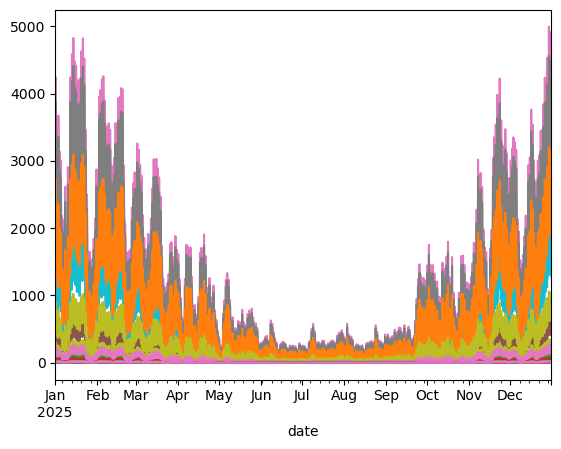

In [8]:
profiles_df.plot(legend=False)

#Gesamtlast aller Gebäude
# profiles_df.sum(axis=1).plot(title="Gesamtwärmebedarf aller Gebäude")

<Axes: xlabel='date'>

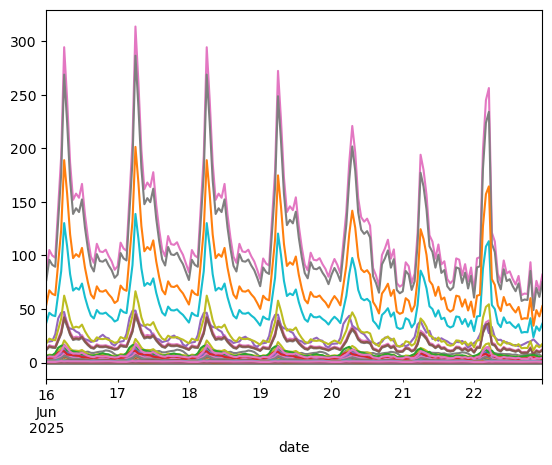

In [9]:
profiles_df[profiles_df.index.isocalendar().week == 25].plot(legend=False)

In [5]:
region = vdi.Region(
    2017,
    climate=vdi.Climate().from_try_data(try_region=12), #TRY-Klimaregion 12 - "Oberrheingraben und unteres Neckartal", Mannheim als Repräsentanzstation
    houses=houses,
    resample_rule="1h"
)

ValueError: The following house types are not supported:
{'name': 243687641, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 5589.0}\n{'name': 243687648, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 1994.0}\n{'name': 243687649, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 746.0}\n{'name': 243687650, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 893.0}\n{'name': 243687652, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 1053.0}\n{'name': 243687659, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 1631.0}\n{'name': 243687661, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 0.0, 'Q_TWW_a': 0.0, 'W_a': 1503.0}\n{'name': 243687669, 'house_type': 'GBD', 'N_Pers': nan, 'N_WE': nan, 'Q_Heiz_a': 10608.420786376017, 'Q_TWW_a': 742.589

In [ ]:
# Code from https://oemof-demand.readthedocs.io/en/latest/vdi4655.html

# Define houses
# houses = [
#     {
#         "name": "EFH_1",
#         "house_type": "EFH",
#         "N_Pers": 3,
#         "N_WE": 1,
#         "Q_Heiz_a": 6000,
#         "Q_TWW_a": 1500,
#         "W_a": 5250,
#         "summer_temperature_limit": 15,
#         "winter_temperature_limit": 5,
#     }
# ]

# Create region
# region = vdi.Region(
#     2017,
#     climate=vdi.Climate().from_try_data(try_region=4),
#     houses=houses,
#     resample_rule="1h"
# )

# Generate load curves
# load_curves = region.get_load_curve_houses()